          A E T H E R I U M   O S   -   v1.0
       The Topological Quantum Fluid Framework
            Auteur : Richard MORIN

=== MODULES DISPONIBLES ===
  1. La Toile Cosmique (Dark Fluid : Matière + Énergie)
  2. L'AGI Fluide (Losange Cognitif : Mémoire Holographique)
  3. Le Trou Noir Fluide (Gel Temporel et Poche d'Éternité)
  4. Viscosité de Collatz (Stabilité Thermodynamique)
  0. Quitter

Entrez le numéro de la simulation à lancer : 2

[+] Lancement de l'AGI Fluide (Losange Cognitif)...
    -> Apprentissage instantané...
    -> Reconstruction associative en cours...


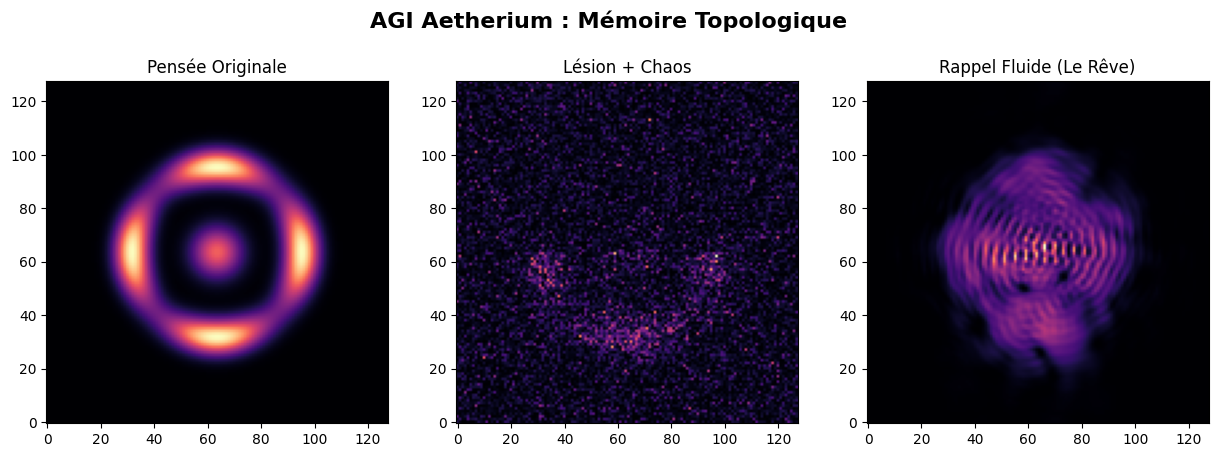

          A E T H E R I U M   O S   -   v1.0
       The Topological Quantum Fluid Framework
            Auteur : Richard MORIN

=== MODULES DISPONIBLES ===
  1. La Toile Cosmique (Dark Fluid : Matière + Énergie)
  2. L'AGI Fluide (Losange Cognitif : Mémoire Holographique)
  3. Le Trou Noir Fluide (Gel Temporel et Poche d'Éternité)
  4. Viscosité de Collatz (Stabilité Thermodynamique)
  0. Quitter


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.





Fermeture d'urgence de l'Aetherium OS.
Traceback (most recent call last):
  File "/tmp/ipykernel_1333/3318370624.py", line 251, in <cell line: 0>
    main_menu()
  File "/tmp/ipykernel_1333/3318370624.py", line 232, in main_menu
    choice = input("\nEntrez le numéro de la simulation à lancer : ")
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 1177, in raw_input
    return self._input_request(
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 1219, in _input_request
    raise KeyboardInterrupt("Interrupted by user") from None
KeyboardInterrupt: Interrupted by user

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)

TypeError: object of type 'NoneType' has no len()

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
AETHERIUM UNIFIED FRAMEWORK - OS LAUNCHER
-----------------------------------------
Auteur : Richard MORIN (GENIUS Activity)
Année  : 2026
Description : Hub central interactif permettant de lancer toutes les
              simulations du modèle Aetherium (Cosmologie, AGI, Mathématiques).
"""

import os
import sys
import time
import torch
import torch.fft
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from matplotlib.colors import hsv_to_rgb

# =====================================================================
# 1. CLASSES ET MOTEURS PHYSIQUES
# =====================================================================

class AetheriumCosmology(torch.nn.Module):
    """Moteur de Genèse Cosmique (Matière Noire & Énergie Sombre)"""
    def __init__(self, N=256, L=50.0, g=1.5, alpha=2.0, dt=0.01, device='cpu'):
        super().__init__()
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.N, self.L, self.g, self.alpha, self.dt = N, L, g, alpha, dt
        x = torch.linspace(-L/2, L/2, N, device=self.device)
        self.X, self.Y = torch.meshgrid(x, x, indexing='ij')
        kx = torch.fft.fftfreq(N, d=L/N, device=self.device) * 2 * np.pi
        ky = torch.fft.fftfreq(N, d=L/N, device=self.device) * 2 * np.pi
        KX, KY = torch.meshgrid(kx, ky, indexing='ij')
        self.K2 = KX**2 + KY**2
        self.kinetic_op = torch.exp(-1j * (self.dt / 4.0) * self.K2)

    def solve_poisson(self, rho):
        rho_diff_hat = torch.fft.fftn(rho - 1.0)
        V_hat = torch.zeros_like(rho_diff_hat)
        mask = self.K2 != 0
        V_hat[mask] = -self.alpha * rho_diff_hat[mask] / self.K2[mask]
        return torch.fft.ifftn(V_hat).real

    def forward(self, psi):
        psi_hat = torch.fft.fftn(psi) * self.kinetic_op
        psi = torch.fft.ifftn(psi_hat)
        rho = torch.abs(psi)**2
        phi_gravite = self.solve_poisson(rho)
        pression_quantique = self.g * rho
        V_eff = phi_gravite + pression_quantique
        psi = psi * torch.exp(-1j * self.dt * V_eff)
        psi_hat = torch.fft.fftn(psi) * self.kinetic_op
        psi = torch.fft.ifftn(psi_hat)
        return psi, rho, phi_gravite, pression_quantique

class AetheriumAGI(torch.nn.Module):
    """Moteur du Losange Cognitif (Mémoire et Rêve Fluide)"""
    def __init__(self, N=128, L=20.0, g=1.5, alpha=4.0, nu_collatz=0.015, dt=0.05, device='cpu'):
        super().__init__()
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.N, self.L, self.g, self.alpha, self.nu, self.dt = N, L, g, alpha, nu_collatz, dt
        x = torch.linspace(-L/2, L/2, N, device=self.device)
        self.X, self.Y = torch.meshgrid(x, x, indexing='ij')
        kx = torch.fft.fftfreq(N, d=L/N, device=self.device) * 2 * np.pi
        ky = torch.fft.fftfreq(N, d=L/N, device=self.device) * 2 * np.pi
        KX, KY = torch.meshgrid(kx, ky, indexing='ij')
        self.K2 = KX**2 + KY**2
        self.kinetic_op = torch.exp(-1j * (self.dt / 4.0) * self.K2)
        self.kinetic_damp = torch.exp(-self.nu * self.dt * self.K2)
        self.phi_memory = torch.zeros((N, N), dtype=torch.float32, device=self.device)

    def imprint_memory(self, psi_target):
        rho = torch.abs(psi_target)**2
        rho_diff_hat = torch.fft.fftn(rho - torch.mean(rho))
        V_hat = torch.zeros_like(rho_diff_hat)
        mask = self.K2 != 0
        V_hat[mask] = -self.alpha * rho_diff_hat[mask] / self.K2[mask]
        self.phi_memory = torch.fft.ifftn(V_hat).real

    def forward(self, psi):
        psi_hat = torch.fft.fftn(psi) * self.kinetic_op * self.kinetic_damp
        psi = torch.fft.ifftn(psi_hat)
        rho = torch.abs(psi)**2
        V_eff = self.g * rho + self.phi_memory
        psi = psi * torch.exp(-1j * self.dt * V_eff) * torch.exp(-self.nu * self.dt * V_eff)
        norm = torch.sqrt(torch.mean(torch.abs(psi)**2))
        psi = psi / norm
        psi_hat = torch.fft.fftn(psi) * self.kinetic_op * self.kinetic_damp
        psi = torch.fft.ifftn(psi_hat)
        return psi

# =====================================================================
# 2. FONCTIONS DE SIMULATION (LES MODULES DE L'OS)
# =====================================================================

def run_cosmic_genesis():
    print("\n[+] Lancement de la Genèse Cosmique (Toile Cosmique)...")
    cosmos = AetheriumCosmology(N=256, L=40.0, g=2.0, alpha=5.0, dt=0.01)
    torch.manual_seed(42)
    bruit_densite = 1.0 + 0.1 * torch.randn((256, 256), device=cosmos.device)
    bruit_phase = 0.1 * torch.randn((256, 256), device=cosmos.device)
    psi = torch.sqrt(torch.abs(bruit_densite)) * torch.exp(1j * bruit_phase)

    for t in range(200):
        psi, rho, phi, p_quant = cosmos(psi)
        if (t+1) % 50 == 0: print(f"    -> Ère cosmique {t+1}/200 atteinte.")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(r"L'Aetherium 'Dark Fluid' : Toile Cosmique", fontsize=16, fontweight='bold')
    axes[0].imshow(rho.cpu().numpy(), cmap='magma', origin='lower')
    axes[0].set_title(r"Matière Noire $|\Psi|^2$")
    axes[1].imshow(phi.cpu().numpy(), cmap='cividis', origin='lower')
    axes[1].set_title(r"Gravité Latente $\Phi$")
    balance = (p_quant - torch.abs(phi)).cpu().numpy()
    axes[2].imshow(balance, cmap='coolwarm', origin='lower', vmin=-np.max(np.abs(balance)), vmax=np.max(np.abs(balance)))
    axes[2].set_title("Énergie Sombre (Rouge) vs Gravité (Bleu)")
    plt.show()

def run_agi_holographic():
    print("\n[+] Lancement de l'AGI Fluide (Losange Cognitif)...")
    cerveau = AetheriumAGI(N=128)
    R = torch.sqrt(cerveau.X**2 + cerveau.Y**2)
    Theta = torch.arctan2(cerveau.Y, cerveau.X)
    concept = torch.exp(-(R - 5.0)**2 / 1.0) * (1.0 + 0.5*torch.cos(4*Theta)) + torch.exp(-R**2 / 2.0)
    psi_target = torch.sqrt(concept) * torch.exp(1j * Theta)

    print("    -> Apprentissage instantané...")
    cerveau.imprint_memory(psi_target)

    psi_corrupted = psi_target.clone()
    psi_corrupted[64:, :] = 0.0 # Amnésie 50%
    psi_corrupted += (torch.randn((128, 128)) + 1j * torch.randn((128, 128))) * 0.5
    rho_corrupted = torch.abs(psi_corrupted)**2

    print("    -> Reconstruction associative en cours...")
    psi_recalled = psi_corrupted.clone()
    for t in range(200):
        psi_recalled = cerveau(psi_recalled)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(r"AGI Aetherium : Mémoire Topologique", fontsize=16, fontweight='bold')
    axes[0].imshow(torch.abs(psi_target)**2, cmap='magma', origin='lower')
    axes[0].set_title("Pensée Originale")
    axes[1].imshow(rho_corrupted.cpu().numpy(), cmap='magma', origin='lower')
    axes[1].set_title("Lésion + Chaos")
    axes[2].imshow((torch.abs(psi_recalled)**2).cpu().numpy(), cmap='magma', origin='lower')
    axes[2].set_title("Rappel Fluide (Le Rêve)")
    plt.show()

def run_time_freezing():
    print("\n[+] Lancement de la Poche d'Éternité (Trou Noir)...")
    N = 256
    x = torch.linspace(-10, 10, N)
    X, Y = torch.meshgrid(x, x, indexing='ij')
    R = torch.sqrt(X**2 + Y**2)
    density = 1.0 + 15.0 * torch.exp(-R**2 / 2.0)
    time_speed = torch.clamp(1.0 - (density / 12.0), min=0.0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(r"Aetherium : Le Temps figé par la Densité", fontsize=16, fontweight='bold')
    im1 = axes[0].imshow(density.numpy(), cmap='inferno', origin='lower')
    axes[0].set_title(r"Densité du Trou Noir $|\Psi|^2$")
    im2 = axes[1].imshow(time_speed.numpy(), cmap='viridis', origin='lower')
    axes[1].set_title(r"Vitesse du Temps $d\theta/dt$ (Bleu = 0, Figé)")
    axes[1].contour(X.numpy(), Y.numpy(), time_speed.numpy(), levels=[0.01], colors='cyan', linewidths=2, linestyles='dashed')
    plt.colorbar(im1, ax=axes[0])
    plt.colorbar(im2, ax=axes[1])
    plt.show()

def run_collatz_viscosity():
    print("\n[+] Lancement de la Synergie Collatz / Navier-Stokes...")
    M = 2048
    row_ind, col_ind, data = [], [], []
    for i in range(M):
        j = (i // 2) % M if i % 2 == 0 else (3 * i + 1) % M
        row_ind.append(i); col_ind.append(j); data.append(1.0)
    P = sparse.csr_matrix((data, (row_ind, col_ind)), shape=(M, M))

    rho = np.ones(M) / M
    history_entropy = []

    print("    -> Calcul de la dissipation fluide...")
    for t in range(100):
        rho_safe = rho[rho > 1e-12]
        history_entropy.append(-np.sum(rho_safe * np.log(rho_safe)))
        rho = rho @ P

    S = np.array(history_entropy)
    t_array = np.arange(100)
    slope, intercept = np.polyfit(t_array[10:], np.log(S[10:]), 1)
    nu = -slope

    print(f"    => Viscosité topologique émergente (nu) = {nu:.4f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(t_array, S, color='red', linewidth=2, label="Entropie (Chaos)")
    ax.plot(t_array, np.exp(intercept) * np.exp(-nu * t_array), 'k--', label=rf"Dissipation $\nu={nu:.4f}$")
    ax.set_title(r"Régularisation de Navier-Stokes par l'Arithmétique", fontweight='bold')
    ax.set_xlabel("Itérations")
    ax.set_ylabel("Entropie")
    ax.grid(True, linestyle=':')
    ax.legend()
    plt.show()

# =====================================================================
# 3. INTERFACE UTILISATEUR (MENU OS)
# =====================================================================

def print_banner():
    os.system('cls' if os.name == 'nt' else 'clear')
    print("=" * 60)
    print("          A E T H E R I U M   O S   -   v1.0")
    print("       The Topological Quantum Fluid Framework")
    print("            Auteur : Richard MORIN")
    print("=" * 60)

def main_menu():
    while True:
        print_banner()
        print("\n=== MODULES DISPONIBLES ===")
        print("  1. La Toile Cosmique (Dark Fluid : Matière + Énergie)")
        print("  2. L'AGI Fluide (Losange Cognitif : Mémoire Holographique)")
        print("  3. Le Trou Noir Fluide (Gel Temporel et Poche d'Éternité)")
        print("  4. Viscosité de Collatz (Stabilité Thermodynamique)")
        print("  0. Quitter")
        print("===========================")

        choice = input("\nEntrez le numéro de la simulation à lancer : ")

        if choice == '1':
            run_cosmic_genesis()
        elif choice == '2':
            run_agi_holographic()
        elif choice == '3':
            run_time_freezing()
        elif choice == '4':
            run_collatz_viscosity()
        elif choice == '0':
            print("\nFermeture de l'Aetherium OS. Au revoir Richard !")
            sys.exit(0)
        else:
            print("\nChoix invalide. Appuyez sur Entrée pour réessayer.")
            input()

if __name__ == "__main__":
    try:
        main_menu()
    except KeyboardInterrupt:
        print("\n\nFermeture d'urgence de l'Aetherium OS.")
        sys.exit(0)